# IEEE-CIS Fraud Detection — Day 1 EDA

Goal: confirm dataset understanding before any modeling.

1. Load and merge transaction + identity data
2. Class balance (`isFraud`)
3. Missingness, especially device fields (known sparsity caveat)
4. Field density for planned graph edges: `card1-6`, `addr1/addr2`, `P_emaildomain`
5. `TransactionAmt` and `TransactionDT` sanity distributions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

## 1. Load and merge

Transaction file is the base; identity file is joined in (not every transaction has an identity row).

In [2]:
DATA_DIR = '../data/raw'

train_txn = pd.read_csv(f'{DATA_DIR}/train_transaction.csv')
train_id = pd.read_csv(f'{DATA_DIR}/train_identity.csv')

print('train_transaction:', train_txn.shape)
print('train_identity:', train_id.shape)

train = train_txn.merge(train_id, on='TransactionID', how='left')
print('merged train:', train.shape)

has_identity = train['DeviceType'].notna().mean()
print(f'{has_identity:.1%} of transactions have a matching identity row')

train_transaction: (590540, 394)
train_identity: (144233, 41)


merged train: (590540, 434)
23.8% of transactions have a matching identity row


## 2. Class balance

IEEE-CIS is known to be heavily imbalanced (~3.5% fraud). Confirm the exact split — this drives the cost-based threshold work later.

isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 3.499%


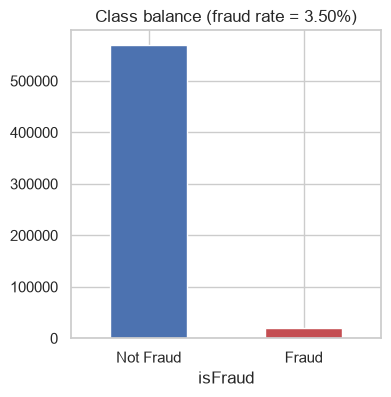

In [3]:
fraud_counts = train['isFraud'].value_counts()
fraud_rate = train['isFraud'].mean()

print(fraud_counts)
print(f'\nFraud rate: {fraud_rate:.3%}')

fig, ax = plt.subplots(figsize=(4, 4))
fraud_counts.plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'])
ax.set_xticklabels(['Not Fraud', 'Fraud'], rotation=0)
ax.set_title(f'Class balance (fraud rate = {fraud_rate:.2%})')
plt.show()

## 3. Missingness

Full null-percentage table, then a specific check on the device fields (`DeviceInfo`, `id_30`-`id_33`) that the project plan already flags as sparse post-masking.

In [4]:
missing_pct = (train.isna().mean() * 100).sort_values(ascending=False)
print('Top 20 most-missing columns:')
print(missing_pct.head(20))

Top 20 most-missing columns:
id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_23    99.124699
id_22    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_04    88.768923
id_03    88.768923
D6       87.606767
id_33    87.589494
id_09    87.312290
dtype: float64


In [5]:
device_cols = ['DeviceType', 'DeviceInfo', 'id_30', 'id_31', 'id_32', 'id_33']
device_cols = [c for c in device_cols if c in train.columns]

device_missing = missing_pct[device_cols]
print('Device field missingness:')
print(device_missing)
print('\n=> Confirms the sparsity caveat: device fields are too sparse to be the primary graph signal.')

Device field missingness:
DeviceType    76.155722
DeviceInfo    79.905510
id_30         86.865411
id_31         76.245132
id_32         86.861855
id_33         87.589494
dtype: float64

=> Confirms the sparsity caveat: device fields are too sparse to be the primary graph signal.


## 4. Field density for planned graph edges

The identity graph (Day 5) links accounts via `card1-6`, `addr1/addr2`, `P_emaildomain`. Confirm these are well-populated enough to be the primary signal.

Non-null (populated) rate for graph-edge fields:
card1            100.000000
card3             99.734988
card6             99.733972
card4             99.732956
card5             99.278796
card2             98.487317
addr1             88.873573
addr2             88.873573
P_emaildomain     84.005148
dtype: float64


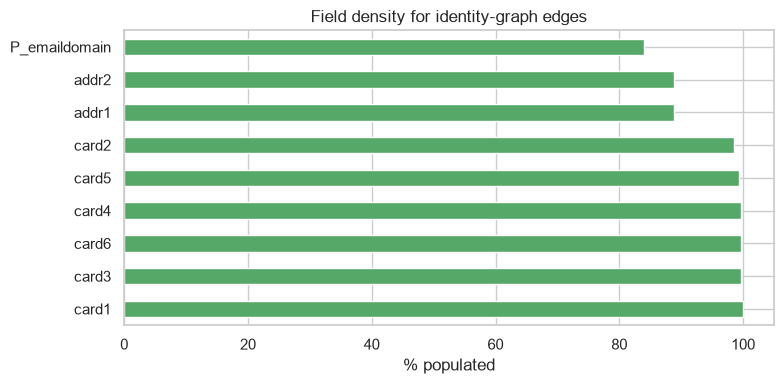

In [6]:
graph_cols = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6',
              'addr1', 'addr2', 'P_emaildomain']
graph_cols = [c for c in graph_cols if c in train.columns]

density = (100 - missing_pct[graph_cols]).sort_values(ascending=False)
print('Non-null (populated) rate for graph-edge fields:')
print(density)

fig, ax = plt.subplots(figsize=(8, 4))
density.plot(kind='barh', ax=ax, color='#55A868')
ax.set_xlabel('% populated')
ax.set_title('Field density for identity-graph edges')
plt.tight_layout()
plt.show()

## 5. Sanity distributions: `TransactionAmt`, `TransactionDT`

In [7]:
print(train['TransactionAmt'].describe())
print()
print('TransactionDT range (seconds from a reference point):')
print(train['TransactionDT'].min(), '-', train['TransactionDT'].max())
print('Span in days:', (train['TransactionDT'].max() - train['TransactionDT'].min()) / (60 * 60 * 24))

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

TransactionDT range (seconds from a reference point):
86400 - 15811131
Span in days: 181.99920138888888


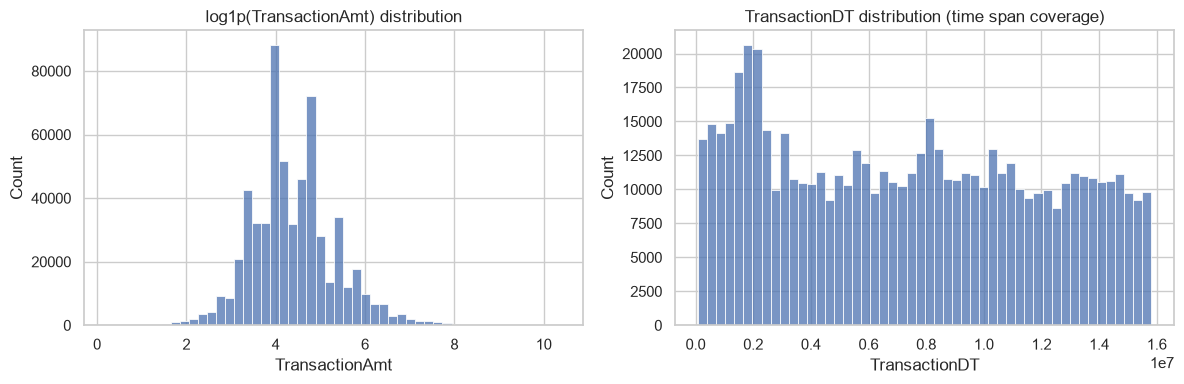

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(np.log1p(train['TransactionAmt']), bins=50, ax=axes[0])
axes[0].set_title('log1p(TransactionAmt) distribution')

sns.histplot(train['TransactionDT'], bins=50, ax=axes[1])
axes[1].set_title('TransactionDT distribution (time span coverage)')

plt.tight_layout()
plt.show()

## Takeaway

_Fill in after running: fraud rate, device-field missingness %, card/addr/email density %, and whether the planned graph-edge fields hold up as the primary signal._